### **Autor**: David Roca Tauste
---

# **📌ACTIVIDAD 1: MNIST**
---

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
print("Claves de mnist: ", mnist.keys())

X, y = mnist["data"], mnist["target"]
print("Dimensiones de X:", X.shape)

Claves de mnist:  dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
Dimensiones de X: (70000, 784)


---
## PASO 1: PREPARAR LOS DATOS

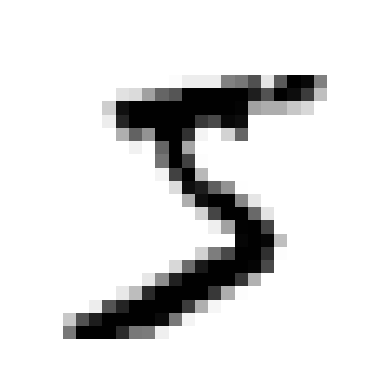

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt

un_digito = X.iloc[0].to_numpy()
imagen_un_digito = un_digito.reshape(28, 28)

plt.imshow(imagen_un_digito, cmap = mpl.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

y = y.iloc[:].to_numpy()
y = y.astype(np.uint8)
print("Nuevo tipo de y[0]:", type(y[0]))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=123)
y_train_2 = (y_train == 2)
y_test_2 = (y_test == 2) # True para todas las instancias que sean del dígito 2

Nuevo tipo de y[0]: <class 'numpy.uint8'>


## ENTREGAR:
### a) Modifica el código para que en la variable un_digito quede cargada la primera instancia que sea un 2.
### b) Cuando particiones los datos y realices otras operaciones aleatorias utiliza una semilla aleatoria que coincida con la longitud de tu nombre concatenada a la de tu primer apellido y concatenada a la de tu segundo apellido. En mi caso sería el valor 449 porque "Jose"=4, "Rosa"=4 y "=9.
### c) Indica cuantas instancias tenemos para entrenar y cuantas para testear.

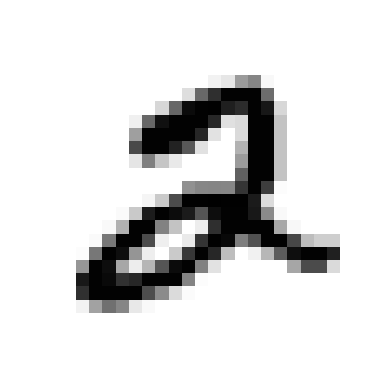

In [5]:
# a) Modifica el código para que en la variable un_digito quede cargada la primera instancia que sea un 2.

indice_dos = np.where(y == 2)[0][0]
un_digito = X.iloc[indice_dos].to_numpy()

imagen_un_digito = un_digito.reshape(28, 28)
plt.imshow(imagen_un_digito, cmap=mpl.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()

In [6]:
# b) Cuando particiones los datos y realices otras operaciones aleatorias utiliza una semilla aleatoria que coincida con la longitud de tu nombre concatenada a la de tu primer apellido y concatenada a la de tu segundo apellido. En mi caso sería el valor 449 porque "Jose"=4, "Rosa"=4 y "=9.

semilla = int(f"{len('David')}{len('Roca')}{len('Tauste')}")
print(semilla)
np.random.seed(semilla)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=semilla)
y_train_2 = (y_train == 2)
y_test_2 = (y_test == 2)

546


In [7]:
# c) Indica cuantas instancias tenemos para entrenar y cuantas para testear.

print(f"Instancias para entrenar: {len(X_train)}")
print(f"Instancias para testear: {len(X_test)}")

Instancias para entrenar: 63000
Instancias para testear: 7000


---
## PASO 2: ENTRENAR UN MODELO QUE IDENTIFIQUE EL DÍGITO 2

In [8]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(random_state=semilla)
sgd.fit(X_train, y_train_2)

SGDClassifier(random_state=546)

In [9]:
print("Predice un 2?: ", sgd.predict([un_digito]))

Predice un 2?:  [ True]


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


In [10]:
from sklearn.model_selection import cross_val_score

cvs = cross_val_score(sgd, X_train, y_train_2, cv=3, scoring="accuracy")
print(f"SGD: Accuracy en 3-folds: {cvs} Media: {cvs.mean()*100:.4f}%")

SGD: Accuracy en 3-folds: [0.97352381 0.97204762 0.9752381 ] Media: 97.3603%


## ENTREGAR:
### a) ¿Qué porcentaje de aciertos tiene el modelo cuando realiza predicciones?
El modelo de SGD tiene una media del 97.3603% de aciertos.

### b) Siendo un clasificador, ¿Si se acerca al 100% es un buen indicador de que ha aprendido bien?
No tiene por qué. Si la accuracy se acerca al 100% puede significar dos cosas:
 - Que ha aprendido bien y generaliza correctamente.
 - Que ha sobreajustado, por lo que el modelo ha memorizado los datos en lugar de aprender patrones generales. Para comprobar si ha ocurrido esto, es necesario evaluar su rendimiento con los datos de prueba.

### c) Escribe el código del clasificador “Siempre Negativo” de abajo y comprueba de la misma manera que hemos realizado con SGDClassifier si hace su trabajo con éxito (ten en cuenta que no necesita entrenamiento, cuando le pregunten si es un 2 siempre va a responder que no) por tanto no lo entrenes, solo lo validas y compruebas sus porcentajes de éxitos con este comportamiento que es independiente de los datos con los que trabaje.

In [11]:
from sklearn.base import BaseEstimator

class DonVangall(BaseEstimator):
    def fit(self, X, y=None):
        pass

    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [12]:
from sklearn.metrics import accuracy_score

siempre_negativo = DonVangall()
predicciones = siempre_negativo.predict(X_test)

precision = accuracy_score(y_test_2, predicciones)
print(f"Precisión del clasificador Siempre Negativo: {precision:.2f}")

Precisión del clasificador Siempre Negativo: 0.90


In [13]:
cvs = cross_val_score(siempre_negativo, X_train, y_train_2, cv=3, scoring="accuracy")
print(f"Siempre Negativo: Accuracy en 3-folds: {cvs} Media: {cvs.mean()*100:.4f}%")

Siempre Negativo: Accuracy en 3-folds: [0.90004762 0.89971429 0.90185714] Media: 90.0540%


### d) A la vista de los resultados del apartado c) ¿La accuracy es fiable para saber si un clasificador es bueno?
En este caso ocurre lo mismo que en la pregunta b). 

No tiene por qué que el clasificador sea bueno. Para saberlo será necesario evaluar su rendimiento con los datos de prueba y así saber si se trata de un buen modelo o si, por lo contrario, tiene overfitting.

---
## PASO 3: VALIDAR EL MODELO CON LA MATRIZ DE CONFUSIÓN

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd, X_train, y_train_2, cv=3)
print("Matriz de confusión:\n", confusion_matrix(y_train_2, y_train_pred))

Matriz de confusión:
 [[56179   555]
 [ 1108  5158]]


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precisión:", precision_score(y_train_2, y_train_pred))
print("recall:", recall_score(y_train_2, y_train_pred) )
print("F1-score:", f1_score(y_train_2, y_train_pred))

Precisión: 0.9028531419569403
recall: 0.8231726779444621
F1-score: 0.8611737206778529


In [16]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_train_2, y_train_pred))

Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.99      0.99     56734
        True       0.90      0.82      0.86      6266

    accuracy                           0.97     63000
   macro avg       0.94      0.91      0.92     63000
weighted avg       0.97      0.97      0.97     63000



## ENTREGAR:
### a) Selecciona la correcta:
Cada fila de la matriz de confusión representa una clase
 - `Real`
 - Predicha

Cada columna de la matriz de confusión representa una clase
 - Real
 - `Predicha`

### b) Para que el clasificador sea bueno ¿Dónde deben estar los valores más altos de la matriz de confusión?
 - `En la diagonal`
 - Fuera de la diagonal

### c) Observa la salida del informe de clasificación e indica la clase con peor accuracy pero no de todos los intentos sino de los intentos que sean positivos (es decir, de todos los positivos cuantos ha clasificado correctamente).
La clase con peor accuracy en los casos positivos es 'True', con un 90% de precisión frente al 98% de precisión en 'False'.

---
## PASO 4: EQUILIBRO PRECISIÓN / RECALL

In [17]:
y_scores = sgd.decision_function([un_digito])
print("Scores del primer 2:", y_scores)

umbral = 0
prediccion_de_un_digito = (y_scores > umbral)
print(f"Con un umbral de {umbral} Un 2 es un 2= {prediccion_de_un_digito}")

Scores del primer 2: [7806.03342798]
Con un umbral de 0 Un 2 es un 2= [ True]


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


In [18]:
umbral = 8000
prediccion_de_un_digito = (y_scores > umbral)
print(f"Con un umbral de {umbral} Un 2 es un 2= {prediccion_de_un_digito}")

Con un umbral de 8000 Un 2 es un 2= [False]


## ENTREGAR:
### a) A la vista del resultado, si subes el umbral ¿Subes la precisión o el recall?
Si le subes el umbral de 0 a 8000 la precisión empeora, debido a que el resultado con umbral de 0 es: '2=2 True' y con umbral de 8000 es: '2=2 False', por lo que el modelo pasa de acertar a fallar.

### b) Si queremos saber cuanto recall vamos a tener si queremos alcanzar una precisión del 90%, lee el texto y completa el código siguiente para conseguir el gráfico de la figura.
Se encuentra en las celdas de abajo.

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

def plot_precision_recall_vs_umbrales(precisiones, recalls, umbrales):
    plt.plot(umbrales, precisiones[:-1], "b--", label="Precisión", linewidth=2)
    plt.plot(umbrales, recalls[:-1], "g-", label="Recall", linewidth=2)

    plt.legend()
    plt.xlabel("Umbrales")
    plt.ylabel("Valores")
    plt.grid(True)
    plt.axis([umbrales[0], umbrales[-1], 0, 1])

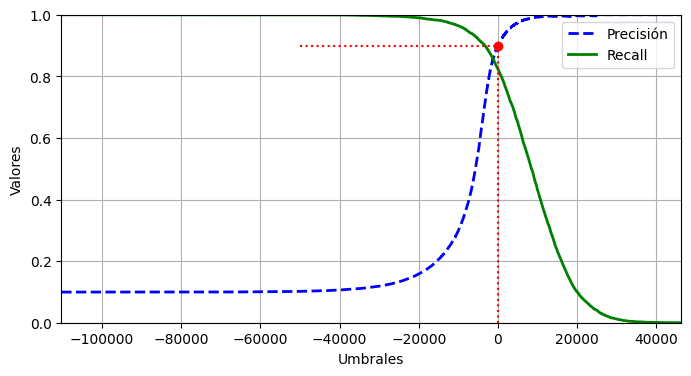

In [20]:
y_scores = cross_val_predict(sgd, X_train, y_train_2, cv=3, method="decision_function")
precisiones, recalls, umbrales = precision_recall_curve(y_train_2, y_scores)
recall_precision_90 = recalls[np.argmax(precisiones >= 0.90)]

umbral_para_precision_90 = umbrales[np.argmax(precisiones >= 0.90)]

plt.figure(figsize=(8, 4))
plot_precision_recall_vs_umbrales(precisiones, recalls, umbrales)

plt.plot([umbral_para_precision_90, umbral_para_precision_90], [0., 0.9], "r:")
plt.plot([-50000, umbral_para_precision_90], [0.9, 0.9], "r:")
plt.plot([umbral_para_precision_90], [0.9], "ro")
plt.show()

In [21]:
umbral_para_precision_90 = umbrales[np.argmax(precisiones >= 0.90)]
print("Umbral para alcanzar precisión del 90%:", umbral_para_precision_90)

y_train_pred_90 = (y_scores >= umbral_para_precision_90)
print("Precisión con umbral", umbral_para_precision_90, "=", precision_score(y_train_2, y_train_pred_90))
print("Recall con umbral", umbral_para_precision_90, "=", recall_score(y_train_2, y_train_pred_90))

Umbral para alcanzar precisión del 90%: -60.93905163174179
Precisión con umbral -60.93905163174179 = 0.9000870322019147
Recall con umbral -60.93905163174179 = 0.8252473667411426


### c) ¿Qué valores de recall vamos a tener si queremos alcanzar una precisión del 90%?
Si queremos alcanzar una precisión del 90%, vamos a tener un valor de recall de: 0.8252473667411426

---
## PASO 5: LA CURVA ROC

## ENTREGAR:
### a) Completa el código de la función plot_curva_roc() sustituyendo cada línea comentada por el código que la implementa.
Se encuentra en la celda de abajo.

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, umbrales = roc_curve(y_train_2, y_scores)

def plot_curva_roc(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.legend(loc="lower right", fontsize=14)
    plt.xlabel("FPR (False Positive Rate)")
    plt.ylabel("TPR (Recall, Sensitivity)")
    plt.grid(True)

### b) ¿Qué AUC tendrá un clasificador binario aleatorio? ¿Y un clasificador binario perfecto?
 - Un clasificador binario aleatorio tendrá aproximadamente un AUC de 0'5, ya que no tiene capacidad de discriminación entre clases y la curva ROC seguirá la diagonal de referencia.
 - Un clasificador binario perfecto tendrá un AUC de 1'0, ya que puede separar completamente las clases sin errores.

### c) Sabiendo que puedes calcular el área bajo la curva con la función roc_auc_score(y_train_2, y_scores) añade el código en una llamada a plot_curva_roc() que genere esta gráfica:
Se encuentra en la celda de abajo.

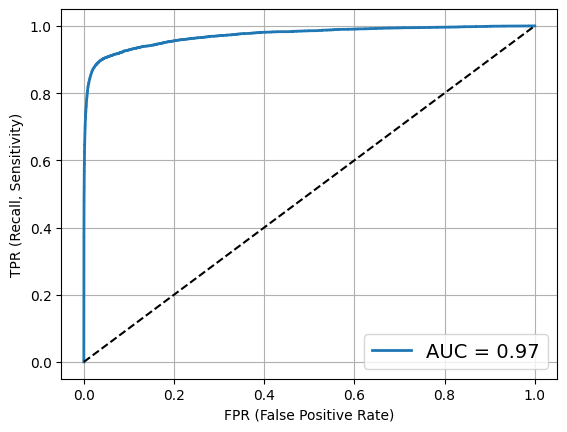

In [23]:
auc = roc_auc_score(y_train_2, y_scores)
plot_curva_roc(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.show()

### d) Tras dibujar el gráfico (en la línea 133) haz una llamada a plot_curva_roc() para dibujar la curva del clasificador Random Forest y muestra el gráfico para que quede como el siguiente.
Se encuentra en la celda de abajo.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=semilla)
y_probs_forest = cross_val_predict(rfc, X_train, y_train_2, cv=3, method="predict_proba")

y_scores_forest = y_probs_forest[:, 1]
fpr_forest, tpr_forest, umbrales_forest = roc_curve(y_train_2, y_scores_forest)

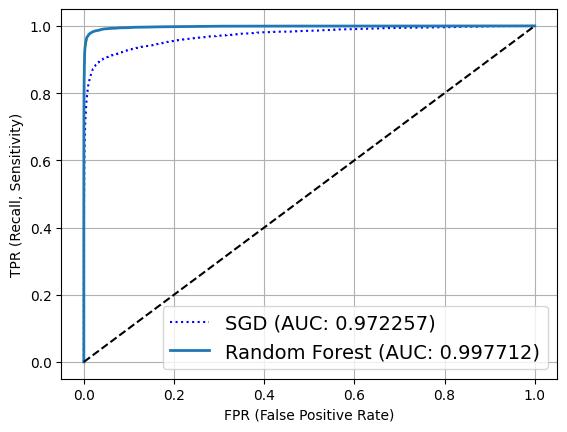

In [25]:
auc_forest = roc_auc_score(y_train_2, y_scores_forest)

plt.plot(fpr, tpr, "b:", label=f"SGD (AUC: {auc:.6f})")
plot_curva_roc(fpr_forest, tpr_forest, label=f"Random Forest (AUC: {auc_forest:.6f})")
plt.show()

### e) Basándonos en la métrica ¿Cuál de los dos clasificadores reconoce mejor el dígito 2?
Basándonos en la métrica, el clasificador que reconoce mejor el dígito 2 es: `Random Forest` con un porcentaje del 0'997712%. Frente al 0'972257% del SGD.

---
## PASO 6: CLASIFICACIÓN MULTICLASE

In [26]:
sgd.fit(X_train, y_train)   # y_train, no es y_train_2
print("Predicción de un 2", sgd.predict([un_digito]))

scores_de_un_digito = sgd.decision_function([un_digito])
print("scores de un_digito", scores_de_un_digito)

Predicción de un 2 [2]
scores de un_digito [[-17107.6901124  -32574.43609925  13078.22506271  -6014.40359082
  -18592.06873133  -7516.00129423 -15192.67232666 -21331.37127034
   -4207.98462159  -3533.84447042]]


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


## ENTREGAR:
### a) En ejecutar las sentencias de la 137 a la 138 habrá tardado algo más de tiempo (si estás realizando la práctica en un jupyter notebook y has dejado este código en su propia celda) ¿Cuánto? ¿Cuántos modelos ha entrenado Scikit-learn? ¿Qué método ha usado?
Ha tardado en ejecutar la celda anterior 2 minutos y 55 segundos.<br>
Scikit-learn ha entrenado solamente un modelo (SGDClassifier).<br>
Ha usado el método 'fit' para entrenar el modelo y 'predict' para clasificar solo un dígito.

### b) ¿Cuántos scores devuelve la sentencia 139? ¿Cuál es la posición del más alto?
Devuelve 10 scores. La posición del más alto es: 13078'22506271.

In [27]:
mayor = np.argmax(scores_de_un_digito)
print("Clases del clasificador:", sgd.classes_)
print("La clase con mayor score:", sgd.classes_[mayor])

Clases del clasificador: [0 1 2 3 4 5 6 7 8 9]
La clase con mayor score: 2


In [ ]:
from sklearn.multiclass import OneVsOneClassifier

ovo = OneVsOneClassifier(SGDClassifier(random_state=semilla))
ovo.fit(X_train.values, y_train) # df.values quita cabeceras del df y no da warning
print("SGD: Prediccion de un dígito 2:", ovo.predict([un_digito]))
print("SGD: Longitud de los estimadores", len(ovo.estimators_))

# Entrenar un bosque aleatorio es más sencillo porque soporta multiclase
rfc.fit(X_train.values, y_train) # Uso values para que no use cabeceras y no de warning
print("Random Forest: Predicción de un digito 2:", rfc.predict([un_digito]))
print("Random Forest: Probabilidades predichas del dígito:", rfc.predict_proba([un_digito]))

SGD: Prediccion de un dígito 2: [2]
SGD: Longitud de los estimadores 45
Random Forest: Predicción de un digito 2: [2]
Random Forest: Probabilidades predichas del dígito: [[0.   0.   0.9  0.02 0.   0.01 0.01 0.03 0.01 0.02]]


In [34]:
print("Random Forest: Longitud de los estimadores", len(rfc.estimators_))

Random Forest: Longitud de los estimadores 100


### c) ¿Cuántos modelos se han entrenado en ovo? ¿Cuántos en rfc? ¿Cuál es el resultado de la línea 150? ¿Si lo hiciésemos con rfc ¿Cuál sería el resultado?
 - En ovo se han entrenado 45 modelos.
 - En rfc se ha entrenado 1 modelo.
 - El resultado de la línea 150 es: 45.
 - Si lo hiciésemos con rfc, el resultado sería: 100.

### d) En el resultado de ejecutar la línea 154 ¿Qué probabilidad da a que el ejemplo sea un 2? ¿Cuál es la siguiente probabilidad más alta? ¿De qué clase se trata?
 - La probabilidad que da a que el ejemplo sea un 2 es: 0'9% (sobre 1).
 - La siguiente probabilidad más alta es 0'03%. Esta probabilidad corresponde a la clase 7.

In [31]:
from sklearn.preprocessing import StandardScaler

cv1 = cross_val_score(sgd, X_train.values, y_train, cv=3, scoring="accuracy")
print("SGD: Accuracy de 3-fold CV:", cv1, f"media: {cv1.mean():.4f}")

escaleitor = StandardScaler()
X_train_escalado = escaleitor.fit_transform(X_train.astype(np.float64))
cv2 = cross_val_score(sgd, X_train_escalado, y_train, cv=3, scoring="accuracy")
print("SGD: Accuracy de 3-folds CV tras escalar:", cv2, f"media: {cv2.mean():.4f}")

SGD: Accuracy de 3-fold CV: [0.85214286 0.87342857 0.88114286] media: 0.8689
SGD: Accuracy de 3-folds CV tras escalar: [0.90328571 0.89204762 0.90619048] media: 0.9005


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:744: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


### e) ¿Cuáles son los valores de cv1 y cv2 y la media? ¿Qué mejora, si la hay, del % medio hay al escalar?
 - Los valores y media de **cv1** son: [0.85214286 0.87342857 0.88114286] media: 0.8689
 - Los valores y media de **cv2** son: [0.90328571 0.89204762 0.90619048] media: 0.9005
 - Sí que hay una mejora al escalar y es de un 0'0316%.

---
## PASO 7: ANÁLISIS DE ERROR

In [32]:
X_test_escalado = escaleitor.transform(X_test.values)
y_test_pred = cross_val_predict(sgd, X_test_escalado, y_test, cv=3)
mc = confusion_matrix(y_test, y_test_pred)

print("Matriz de confusión de SGD:\n", mc)

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:744: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:744: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Matriz de confusión de SGD:
 [[667   0   3   3   1   6   6   1  11   0]
 [  0 718   5   3   1   5   3   1  23   2]
 [  8   5 630  18   6   1  14   7  33   2]
 [  3   2  19 635   0  26   6   9  33  10]
 [  4   1   4   1 626   0   6   6  16  36]
 [  5   5   6  29   7 484  16   2  43  10]
 [  4   4   5   0  14  11 681   0  11   0]
 [  3   3   7  10   4   3   1 609  13  30]
 [  6  12  10  22   0  18   4   3 605  12]
 [  5   5   2   8  29   4   0  31  12 566]]


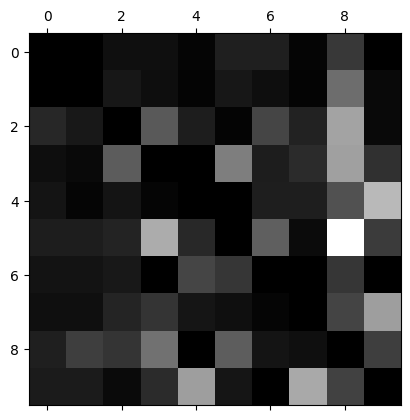

In [33]:
suma_filas = mc.sum(axis=1, keepdims=True)
mc_normalizada = mc / suma_filas

np.fill_diagonal(mc_normalizada, 0)
plt.matshow(mc_normalizada, cmap=plt.cm.gray)
plt.show()